In [1]:
%load_ext autoreload
%autoreload 2

In [16]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("../../../")
import data_loading as dl
from importlib import reload
reload(dl)

from microfit import run_plotter as rp
from microfit import histogram as hist

from microfit import variable_definitions as vdef
from microfit import selections

from microfit import detsys

In [3]:
keep_vars = [
    "Signal_1e1p", "mc_signal_1e1p", "nu_pdg", "TrueElecIdx", "TrueLeadProtonIdx", "InFV", "HasNoMesons",
    "TrueNElec", "TrueNProt", "TrueDeltaPT", "TrueDeltaAlphaT", "TruePN", "TrueAlpha3D",
    "nproton", "npion", "npi0", "nelec", "nmuon", "isVtxInFiducial",
    "Sel_1e1p", "sel_1e1p_w_cuts", "RecoElectronCandidateIdx", "RecoLeadProtonCandidateIdx", "InFV_reco",
    "RecoElecPassMomCut", "RecoLeadProtonPassMomCut", "n_reco_tracks", "n_reco_showers",
    "RecoDeltaPT", "RecoDeltaAlphaT", "RecoPN", "RecoAlpha3D", "RecoECal", "Reco_mag_q", "RecoPL",
    "nslice", "selected", "shr_energy_tot_cali", "_opfilter_pe_beam", "_opfilter_pe_veto", "bnbdata", "extdata",
    "CosmicIPAll3D", "hits_ratio", "shrmoliereavg", "subcluster", "trkfit", "trkshrhitdist2", "tksh_distance",
    "shr_tkfit_nhits_tot", "shr_tkfit_dedx_max", "tksh_angle", "shr_trk_len", "reco_e",
    "RecoLeadProton_trk_len", "RecoLeadProton_trk_trunk_dEdx_y", "RecoLeadProton_dEdx_y_per_trklen",
    "RecoLeadProtonCandidate_trk_pid", "RecoElectronCandidate_shr_pid", "RecoElectron_conversion_dist",
    "pi0_radlen1", "pi0_radlen2", "pi0_score", "nonpi0_score", "bkg_score",
    "RecoElecE", "RecoElecModMom", "RecoElecMomX", "RecoElecMomY", "RecoElecMomZ",
    "RecoLeadProtonKE", "RecoLeadProtonModMom", "RecoLeadProtonMomX", "RecoLeadProtonMomY", "RecoLeadProtonMomZ",
    "ccnc",
]
# If needed, add TKI ingredients to this list

In [4]:
RUN = ["3"]
#RUN = ["1","2","3_nocrt","3_crt","4b","4c","4d","5"]
#RUN = ["1","2","3","4b","4c","4d","5"] #important that it's a string 1) new format to include latest runs 2) to include 'mc_pdg' otherwise it gets dropped
blinded = True
data="nuwro_fd"

rundata, mc_weights, data_pot = dl.load_runs(
    RUN,
    data=data,
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=False,
    loadsystematics=True,
    numupresel=False,
    loadnumuvariables=False,
    use_bdt=True,
    load_lee=False,
    load_nue_tki=True,
    #keep_columns=keep_vars,
    blinded=blinded,
    load_crt_vars=False,
    enable_cache=True,
)

Loading run 3


../../../data_loading.py:2690: RuntimeWarning: divide by zero encountered in true_divide
  mc_pots = data_pots / weights_arr  # this is an array


In [5]:
run_combo = "Run"
for run in RUN:
    run_combo += run
print(run_combo)

Run3


### Calculating the integrated flux

In [6]:
# Zarko Pavlovic, Jun 22 2020
# /pnfs/uboone/persistent/uboonebeam/bnb_gsimple/bnb_gsimple_fluxes_01.09.2019_463_hist/readme.txt

Nominal_UB_XY_Surface = 256.35*233. # cm2
SoftFidSurface = 236. * 210.  # cm2
POTPerSpill = 4997.*5e8

# import uproot

# FluxFile = uproot.open('/pnfs/uboone/persistent/uboonebeam/bnb_gsimple/bnb_gsimple_fluxes_01.09.2019_463_hist/MCC9_FluxHist_volTPCActive.root')#['hEnue_cv']
# HistoFlux = FluxFile['hEnue_cv']
HistoFlux_int = 593641.00 # retrieved from the root file itself by running hEnue_cv->Integral()
#HistoFlux_int = 1.1007862e+08 # for hEnumu_cv

IntegratedFlux = (HistoFlux_int * data_pot / POTPerSpill / Nominal_UB_XY_Surface)
print(IntegratedFlux)

1149616885.7718787


### Extracting the covariance matrix using microfit

In [7]:
with open(f'unfolding_inputs_{data}_{run_combo}.txt', 'w') as f:
    f.writelines(["Data POT = ", f"{data_pot} \n"])
    f.writelines(["Integrated flux = ", f"{IntegratedFlux} \n"])
    f.write("\nCovariance Matrices:\n")

('RecoDeltaPT', None, None, '$\\delta p_T$ [GeV/c]', False, None, [0, 0.3, 1.7])



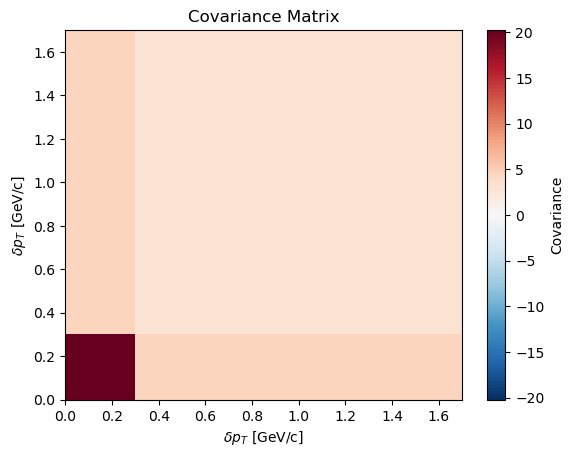

Covariance matrix for RecoDeltaPT : [[20.24183617  4.58544443]
 [ 4.58544443  2.94746783]]

('RecoDeltaAlphaT', None, None, '$\\delta \\alpha_T$ [degrees]', False, None, [0, 80, 180])



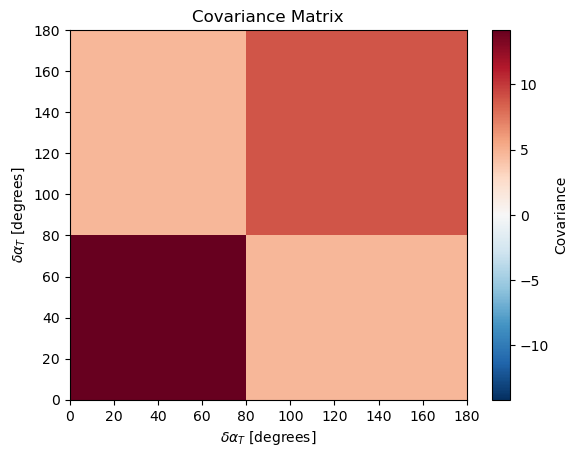

Covariance matrix for RecoDeltaAlphaT : [[14.1653368   4.65344266]
 [ 4.65344266  8.89699111]]

('RecoPN', None, None, '$p_n$ [GeV/c]', False, None, [0, 0.3, 1.7])



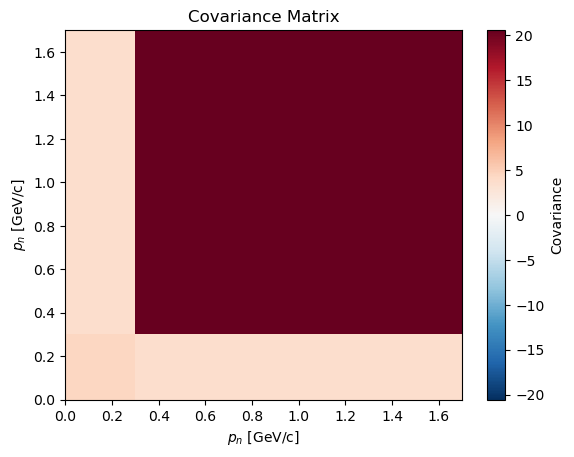

Covariance matrix for RecoPN : [[ 4.49254452  3.6490091 ]
 [ 3.6490091  20.5596108 ]]

('RecoAlpha3D', None, None, '$\\alpha_{3D}$ [degrees]', False, None, [0, 90, 180])



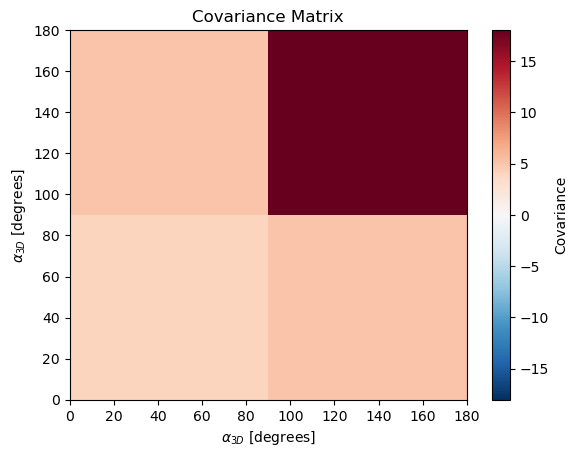

Covariance matrix for RecoAlpha3D : [[ 4.00627516  5.16017051]
 [ 5.16017051 18.04259704]]



<Figure size 640x480 with 0 Axes>

In [20]:
selection = "OnePBDT"
preselection = "OneP_new"

all_mc = pd.concat([df for k, df in rundata.items() if k!='data'])
all_sig = all_mc.query("category_1e1p == 12", engine='python')

for binning_def in vdef.TKI_variables_1e1p:
    # some binning definitions have more than 4 elements,
    # we ignore the last ones for now
    #binning = hist.Binning.from_config(*binning_def[:4])
    binning = hist.Binning.from_config(*binning_def)  # for variable bin sizes
    print(binning_def)
    print()
    label = binning_def[0].lstrip("Reco")
    #################################################################################
    # Getting the covariance matrix
    
    if data == "nuwro_fd":
        # Getting only xsec cov matrix and stats matrix for NuWro fakedata studies
        
        # Stat cov
        #(included by default - just need to turn flags off for syst errors)
        # Hence, will need to subtract stat_cov when calculating all the individual syst error contributions
        signal_generator = hist.RunHistGenerator(
            rundata,
            binning.copy(),
            data_pot=data_pot,
            selection=selection,
            preselection=preselection,
            sideband_generator=None,
            uncertainty_defaults=None,
            detvar_data=None,
            normalization_uncertainty=None
        )
    
        total_prediction = signal_generator.get_total_prediction(include_multisim_errors=False, add_precomputed_detsys=False, smooth_detsys_variations=False)
        flux_norm_total_prediction_stat = total_prediction #/ IntegratedFlux
        stat_cov = flux_norm_total_prediction_stat.covariance_matrix
        #stat_error = np.sqrt(np.diagonal(stat_cov)) / bin_counts
        
        # GENIE cov
        mc_hist_generator = signal_generator.mc_hist_generator
    
        # GENIE multisim
        genie_cov = (mc_hist_generator.calculate_multisim_uncertainties(multisim_weight_column="weightsGenie")) #/ IntegratedFlux**2
        #genie_error = np.sqrt(np.diagonal(genie_cov)) / bin_counts
        #print('genie error:', genie_error)
        #print()

        # GENIE Unisim
        genie_unisim_cov = (mc_hist_generator.calculate_unisim_uncertainties()) #/ IntegratedFlux**2
        #genie_unisim_error = np.sqrt(np.diagonal(genie_unisim_cov)) / bin_counts
        #print('genie unisim error:', genie_unisim_error)
        #print()
        
        cov = genie_cov + genie_unisim_cov + stat_cov
        
        # Plotting the cov matrix 
        
        if binning_def[1] == None:
            edges = binning.bin_edges
        else:
            edges = binning.bin_centers
        
        X, Y = np.meshgrid(edges,edges)
        max_val = np.max(np.abs(cov))
        plt.pcolormesh(X, Y, cov, cmap="RdBu_r", vmin=-max_val, vmax=max_val, shading='flat') #, norm=LogNorm())
        plt.colorbar(label = "Covariance")
        plt.xlabel(f'{binning.variable_tex}')
        plt.ylabel(f'{binning.variable_tex}')
        plt.title(f"Covariance Matrix")
        
        
        plt.savefig(f'analysis_plots/unfolding_inputs/covariance_matrix_{data}_{run_combo}_{label}_{binning_def[1]}bins.pdf', bbox_inches='tight')
        plt.savefig(f'analysis_plots/unfolding_inputs/covariance_matrix_{data}_{run_combo}_{label}_{binning_def[1]}bins.png', bbox_inches='tight')
        plt.show()
        plt.clf()
    
    else:
    
        # Load detvars
        detvar_data = detsys.make_variations(
        run_numbers=RUN,
        data="bnb",
        binning=binning.copy(),
        selection=selection,
        preselection=preselection,
        use_kde_smoothing=False,
        make_plots=False,
        plot_output_dir= "/exp/uboone/app/users/mmoudgal/PELEE/sandbox/mmoudgalya/analysis_1e1p/analysis_plots/detsys/",
        enable_detvar_cache=True,
        detvar_cache_dir="/exp/uboone/data/users/mmoudgal/PELEE/detvar_cached_dataframes/",
        extra_selection_query=None,
        show_plots=True,
        #variations=detector_variations,
        #**dl_kwargs,
        loadpi0variables=False,
        loadshowervariables=True,
        loadrecoveryvars=False,
        loadsystematics=True,
        numupresel=False,
        loadnumuvariables=False,
        use_bdt=True,
        load_lee=False,
        load_nue_tki=True,
        keep_columns=keep_vars,
        blinded=blinded,
        load_crt_vars=False,
        enable_cache=True,
        )

        # Total error
        signal_generator = hist.RunHistGenerator(
            rundata,
            binning.copy(),
            data_pot=data_pot,
            selection=selection,
            preselection=preselection,
            sideband_generator=None,
            uncertainty_defaults=None,
            detvar_data=detvar_data,
            normalization_uncertainty=[0.01,0.02]
        )
        total_prediction = signal_generator.get_total_prediction(include_multisim_errors=True, add_precomputed_detsys=True, smooth_detsys_variations=False)

        print(f"binning_def[0] bin counts:", total_prediction.bin_counts)
        print()

        flux_norm_total_prediction = total_prediction / IntegratedFlux
        fig, ax = plt.subplots()
        flux_norm_total_prediction.draw_covariance_matrix(ax=ax, as_correlation=False)
        plt.savefig(f'analysis_plots/unfolding_inputs/covariance_matrix_{data}_{run_combo}_{label}_{binning_def[1]}bins.pdf', bbox_inches='tight')
        plt.savefig(f'analysis_plots/unfolding_inputs/covariance_matrix_{data}_{run_combo}_{label}_{binning_def[1]}bins.png', bbox_inches='tight')
        plt.show()
        plt.clf()

        cov = total_prediction.covariance_matrix
        
    print('Covariance matrix for', binning_def[0], ':', cov)
    print()
    
    # writing these to a file
    cov_str = "{"
    for i in range(cov.shape[0]):
        for j in range(cov.shape[1]):
            #print(cov[i][j])
            cov_str += f"{cov[i][j]},"
    cov_str = cov_str[:-1] # to remove the last comma
    cov_str += "};"
    # print(cov_str)
    with open(f'unfolding_inputs_{data}_{run_combo}.txt', 'a') as f:
        f.write(f"\n{label}:\n")
        f.writelines([f"covariance", " = ", f"{cov_str} \n"])

In [18]:
print(binning.bin_edges)
print(binning.bin_centers)

[0.   0.17 0.34 0.51 0.68 0.85 1.02 1.19 1.36 1.53 1.7 ]
[0.085 0.255 0.425 0.595 0.765 0.935 1.105 1.275 1.445 1.615]


('RecoDeltaPT', None, None, '$\\delta p_T$ [GeV/c]', False, None, [0, 0.3, 1.7])
Loading devar histograms from file: /exp/uboone/data/users/mmoudgal/PELEE/detvar_cached_dataframes//run_3_RecoDeltaPT_bnb.json
Making plots for mc
Making plots for nue


ValueError: Binning of detector variations does not match binning of main histogram.

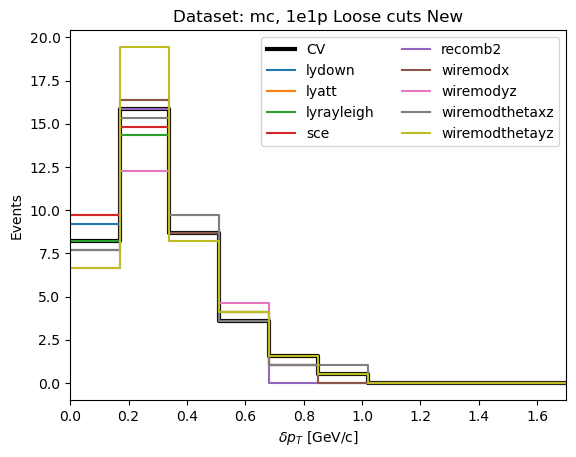

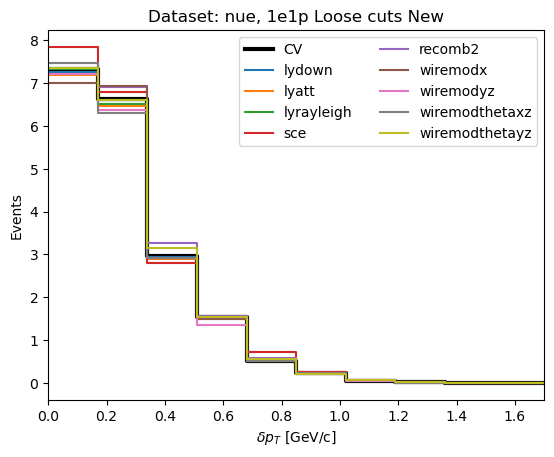

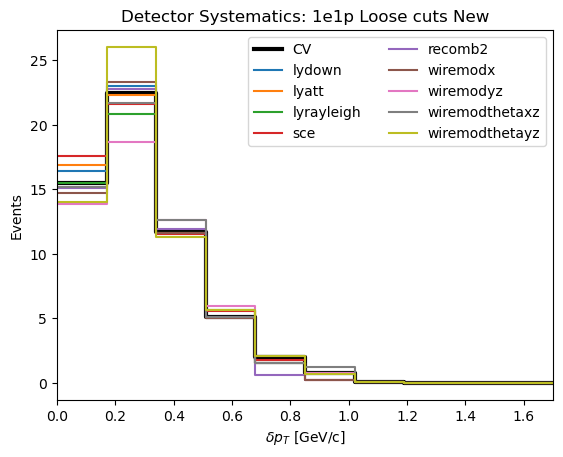

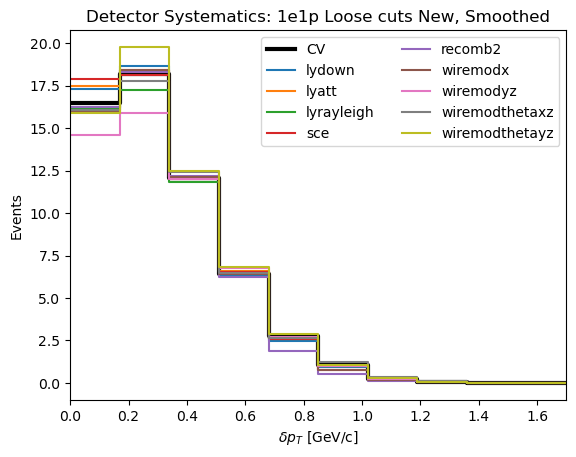

In [15]:
selection = "OnePBDT"
preselection = "OneP_new"

detector_variations = ["cv","lydown","lyatt","lyrayleigh","sce","recomb2","wiremodx","wiremodyz","wiremodthetaxz","wiremodthetayz"]

for binning_def in vdef.TKI_variables_1e1p:
    # some binning definitions have more than 4 elements,
    # we ignore the last ones for now
    #binning = hist.Binning.from_config(*binning_def[:4])
    binning = hist.Binning.from_config(*binning_def)  # for variable bin sizes
    print(binning_def)
    
    # Load detvars
    detvar_data = detsys.make_variations(
    run_numbers=RUN,
    data=data,
    binning=binning.copy(),
    selection=selection,
    preselection=preselection,
    use_kde_smoothing=False,
    make_plots=True,
    plot_output_dir= "/exp/uboone/app/users/mmoudgal/PELEE/sandbox/mmoudgalya/analysis_1e1p/analysis_plots/detsys/",
    enable_detvar_cache=True,
    detvar_cache_dir="/exp/uboone/data/users/mmoudgal/PELEE/detvar_cached_dataframes/",
    extra_selection_query=None,
    show_plots=True,
    variations=detector_variations,
    #**dl_kwargs,
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=False,
    loadsystematics=True,
    numupresel=False,
    loadnumuvariables=False,
    use_bdt=False,
    load_lee=False,
    load_nue_tki=True,
    keep_columns=keep_vars,
    blinded=blinded,
    load_crt_vars=False,
    enable_cache=True,
    )
    
    signal_generator = hist.RunHistGenerator(
        rundata,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
        detvar_data=detvar_data,
        normalization_uncertainty=[0.01,0.02]
    )
    total_prediction = signal_generator.get_total_prediction(include_multisim_errors=True, add_precomputed_detsys=True)
    print(f"binning_def[0] bin counts:", total_prediction.bin_counts)

    flux_norm_total_prediction = total_prediction / IntegratedFlux
    fig, ax = plt.subplots()
    flux_norm_total_prediction.draw_covariance_matrix(ax=ax, as_correlation=False)
    label = binning_def[0].lstrip("Reco")
    plt.savefig(f'analysis_plots/unfolding_inputs/covariance_matrix_{data}_{run_combo}_{label}_{binning_def[1]}bins.pdf', bbox_inches='tight')
    plt.savefig(f'analysis_plots/unfolding_inputs/covariance_matrix_{data}_{run_combo}_{label}_{binning_def[1]}bins.png', bbox_inches='tight')
    plt.show()
    plt.clf()
    
    cov = flux_norm_total_prediction.covariance_matrix
    print('Covariance matrix for', binning_def[0], ':', cov)
    
    # writing these to a file
    cov_str = "{"
    for i in range(cov.shape[0]):
        for j in range(cov.shape[1]):
            #print(cov[i][j])
            cov_str += f"{cov[i][j]},"
    cov_str = cov_str[:-1] # to remove the last comma
    cov_str += "};"
    # print(cov_str)
    with open(f'unfolding_inputs_{run_combo}.txt', 'a') as f:
        f.writelines([f"{label}", " = ", f"{cov_str} \n"])